In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('TRAIN-2.csv')
df['Date'] = pd.to_datetime(df['Date'])


daily = df.groupby('Date')['Sales'].sum().reset_index()
daily.columns = ['Date', 'Total_Sales']
daily = daily.sort_values('Date').reset_index(drop=True)

daily.head()

,Date,Total_Sales
0,2018-01-01,15345484.5
1,2018-01-02,19592415.0
2,2018-01-03,18652527.0
3,2018-01-04,19956267.0
4,2018-01-05,22902651.0


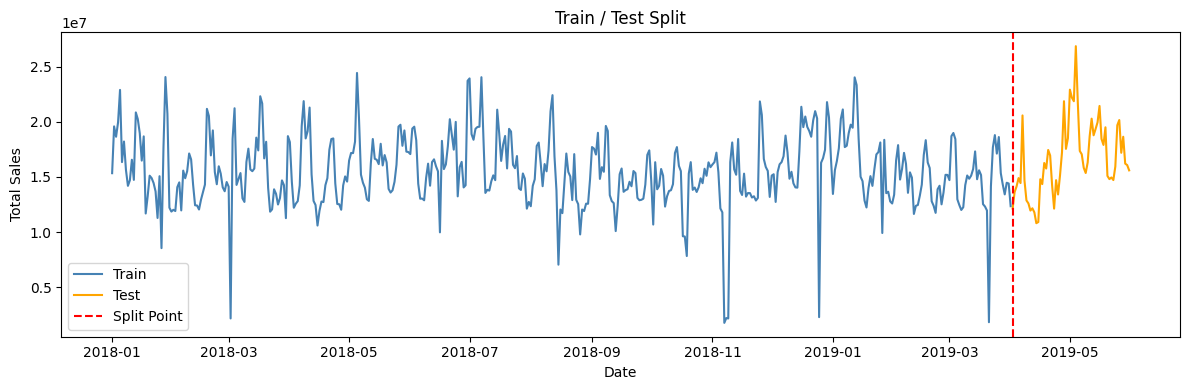

In [5]:
split = len(daily) - 60

train = daily.iloc[:split].copy()
test  = daily.iloc[split:].copy()

plt.figure(figsize=(12, 4))
plt.plot(train['Date'], train['Total_Sales'], label='Train', color='steelblue')
plt.plot(test['Date'], test['Total_Sales'], label='Test', color='orange')
plt.axvline(test['Date'].iloc[0], color='red', linestyle='--', label='Split Point')
plt.title('Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

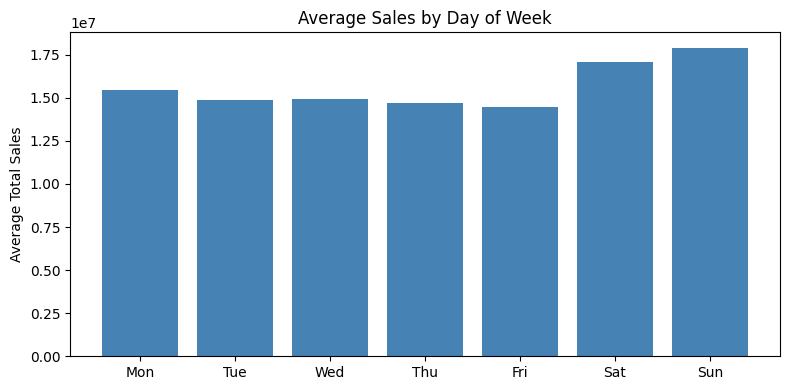

In [6]:
# Average sales by day of week
daily['DayOfWeek'] = daily['Date'].dt.dayofweek
dow_avg = daily.groupby('DayOfWeek')['Total_Sales'].mean()

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 4))
plt.bar(day_names, dow_avg.values, color='steelblue')
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Total Sales')
plt.tight_layout()
plt.show()


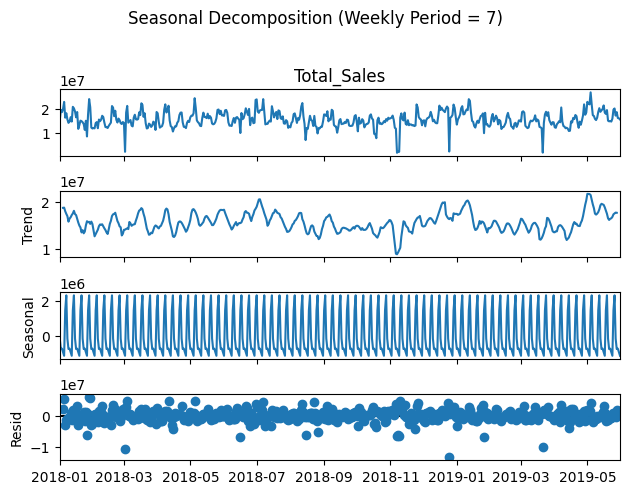

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = daily.set_index('Date')['Total_Sales']

result = seasonal_decompose(ts, model='additive', period=7)
result.plot()
plt.suptitle('Seasonal Decomposition (Weekly Period = 7)', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
naive_pred = np.full(len(test), train['Total_Sales'].iloc[-1])

print("Naive prediction :", naive_pred[0])

Naive prediction : 12349737.0


In [10]:
# Seasonal Naive
seasonal_naive_pred = []

last_week = train['Total_Sales'].iloc[-7:].values

for i in range(len(test)):
    seasonal_naive_pred.append(last_week[i % 7])

seasonal_naive_pred = np.array(seasonal_naive_pred)
print("First 7 predictions :", seasonal_naive_pred[:7])

First 7 predictions : [18624411. 15350445. 14320641. 13419201. 14478648. 14410761. 12349737.]


In [11]:
# Moving Average
window = 7
ma_value = train['Total_Sales'].iloc[-window:].mean()
ma_pred = np.full(len(test), ma_value)

print("Moving Average (7-day) prediction :", round(ma_value, 2))

Moving Average (7-day) prediction : 14707692.0


In [12]:
# Drift forecast
first_val = train['Total_Sales'].iloc[0]
last_val  = train['Total_Sales'].iloc[-1]
n_train   = len(train)

drift_pred = []
for h in range(1, len(test) + 1):
    pred = last_val + h * (last_val - first_val) / (n_train - 1)
    drift_pred.append(pred)

drift_pred = np.array(drift_pred)
print("Drift predictions :", drift_pred[:5].round(2))

Drift predictions : [12343152.94 12336568.88 12329984.82 12323400.76 12316816.7 ]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test['Total_Sales'].values

def calc_metrics(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

results = []
results.append(calc_metrics('Naive', actual, naive_pred))
results.append(calc_metrics('Seasonal Naive', actual, seasonal_naive_pred))
results.append(calc_metrics('Moving Average (7)', actual, ma_pred))
results.append(calc_metrics('Drift', actual, drift_pred))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Model        MAE       RMSE
             Naive 4454821.09 5432252.56
    Seasonal Naive 3463831.54 4336033.07
Moving Average (7) 2914360.44 3844013.36
             Drift 4637419.04 5623275.18


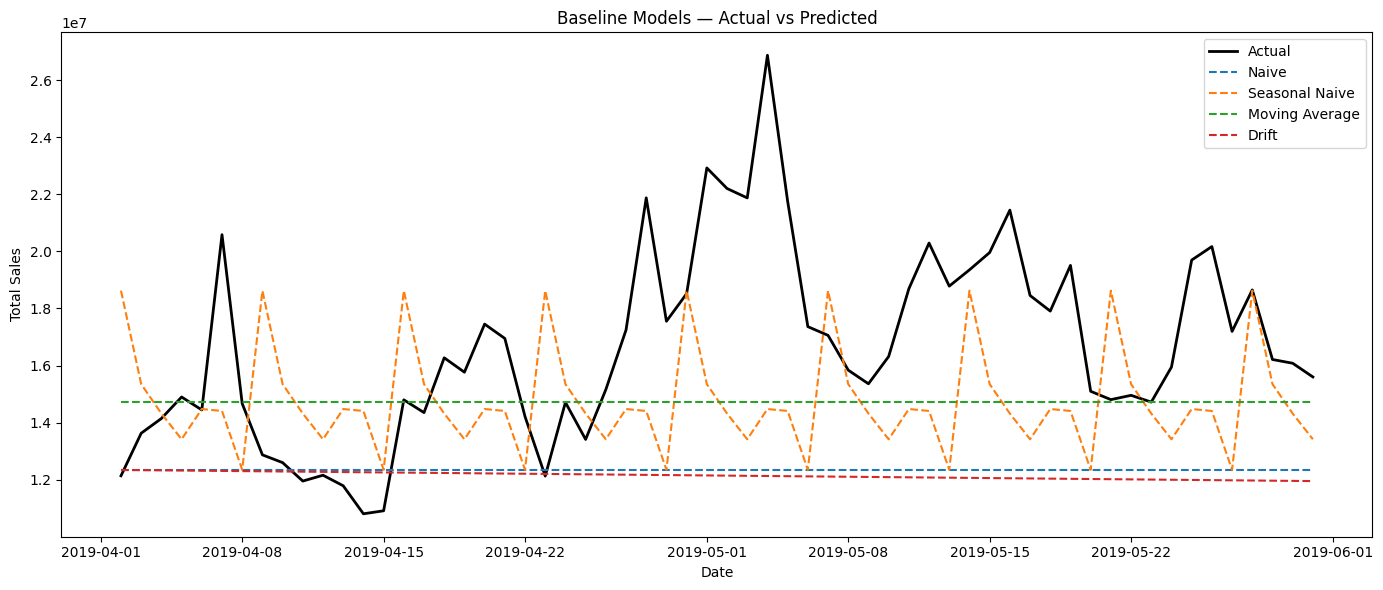

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(test['Date'].values, actual, color='black', linewidth=2, label='Actual')
plt.plot(test['Date'].values, naive_pred, linestyle='--', label='Naive')
plt.plot(test['Date'].values, seasonal_naive_pred, linestyle='--', label='Seasonal Naive')
plt.plot(test['Date'].values, ma_pred, linestyle='--', label='Moving Average')
plt.plot(test['Date'].values, drift_pred, linestyle='--', label='Drift')
plt.title('Baseline Models — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# First check if data is stationary
adf_result = adfuller(train['Total_Sales'])
print("ADF Statistic :", round(adf_result[0], 4))
print("p-value :", round(adf_result[1], 4))

if adf_result[1] < 0.05:
    print("\n Data is STATIONARY (p < 0.05) → d = 0")
    d = 0
else:
    print("\n Data is NOT stationary → d = 1")
    d = 1

ADF Statistic : -4.2956
p-value : 0.0005

 Data is STATIONARY (p < 0.05) → d = 0


In [16]:
train_series = train.set_index('Date')['Total_Sales']

best_aic = np.inf
best_order = None

print("Trying different ARIMA orders...\n")

for p in [1, 2, 3]:
    for q in [0, 1, 2]:
        try:
            model = ARIMA(train_series, order=(p, d, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
                print(f"  ARIMA{(p, d, q)} — AIC: {round(fitted.aic, 2)}")
        except:
            pass

print(f"\nBest ARIMA order: {best_order} with AIC: {round(best_aic, 2)}")

Trying different ARIMA orders...

  ARIMA(1, 0, 0) — AIC: 14816.19


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

  ARIMA(3, 0, 2) — AIC: 14788.61

Best ARIMA order: (3, 0, 2) with AIC: 14788.61


In [18]:

arima_model = ARIMA(train_series, order=best_order)
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=60)
arima_pred = arima_forecast.values



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with weekly seasonality (s=7)
# We use simple seasonal orders to keep it beginner-friendly

sarima_model = SARIMAX(train_series,order=best_order,seasonal_order=(1, 0, 1, 7))     

sarima_fit = sarima_model.fit(disp=False)
print("SARIMA AIC :", round(sarima_fit.aic, 2))

sarima_forecast = sarima_fit.forecast(steps=60)
sarima_pred = sarima_forecast.values

print("SARIMA Forecast (first 5) :", sarima_pred[:5].round(2))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA AIC : 14784.89
SARIMA Forecast (first 5) : [12500559.07 13393874.35 14025059.99 14773135.15 17826675.44]


In [21]:
from prophet import Prophet

# Prophet needs columns: ds (date) and y (value)
prophet_train = train[['Date', 'Total_Sales']].copy()
prophet_train.columns = ['ds', 'y']

# Fit Prophet model
prophet_model = Prophet(yearly_seasonality=True,weekly_seasonality=True,daily_seasonality=False)
prophet_model.fit(prophet_train)

print(" Prophet model fitted!")

Importing plotly failed. Interactive plots will not work.
11:30:01 - cmdstanpy - INFO - Chain [1] start processing
11:30:01 - cmdstanpy - INFO - Chain [1] done processing


 Prophet model fitted!


In [22]:
future = prophet_model.make_future_dataframe(periods=60)


prophet_result = prophet_model.predict(future)

prophet_pred = prophet_result['yhat'].iloc[-60:].values

print("Prophet Forecast (first 5) :", prophet_pred[:5].round(2))

Prophet Forecast (first 5) : [13811026.   13755365.71 13516570.98 13307283.21 16022672.02]


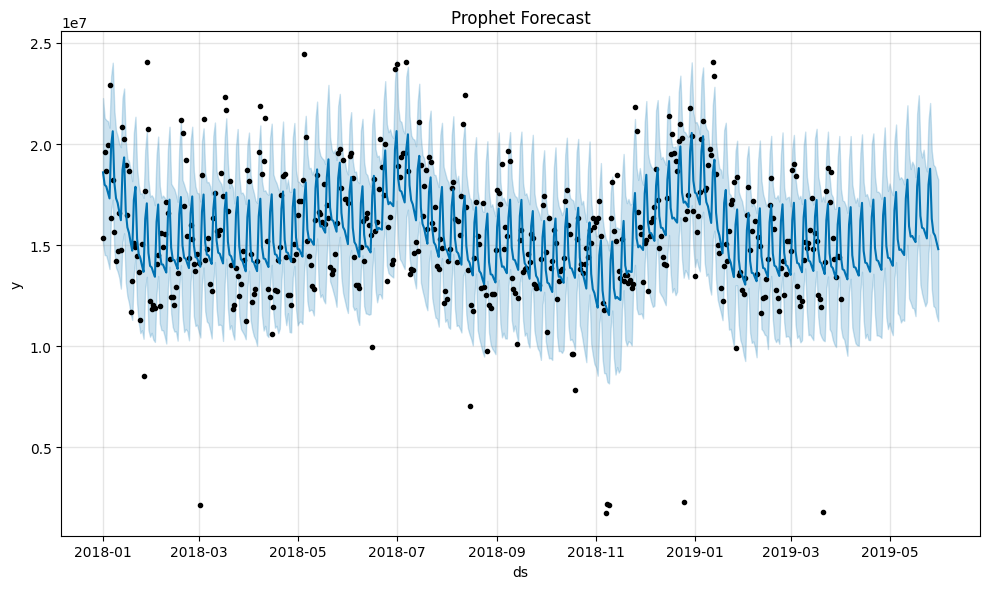

In [23]:
# Prophet built-in plot 
prophet_model.plot(prophet_result)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.show()

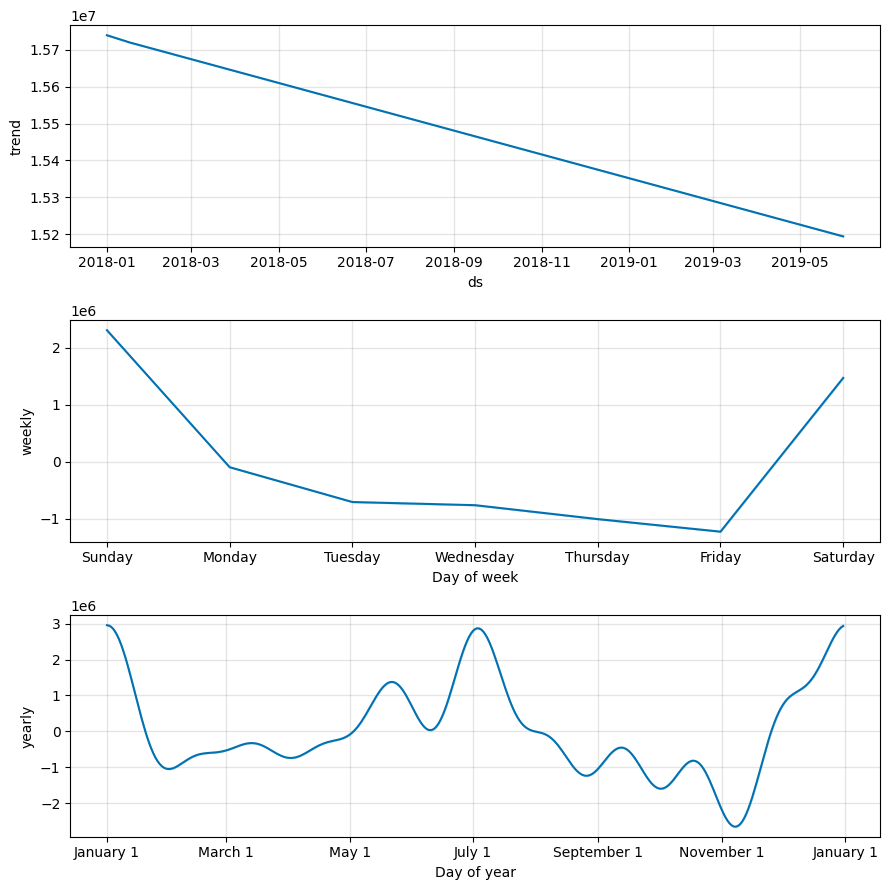

In [24]:
# Prophet components
prophet_model.plot_components(prophet_result)
plt.tight_layout()
plt.show()

In [25]:

results.append(calc_metrics('ARIMA', actual, arima_pred))
results.append(calc_metrics('SARIMA', actual, sarima_pred))
results.append(calc_metrics('Prophet', actual, prophet_pred))

final_results = pd.DataFrame(results)

final_results = final_results.sort_values('MAE').reset_index(drop=True)


print("      MODEL COMPARISON (sorted by MAE)")

print(final_results.to_string(index=False))

print(f"\n Best Model: {final_results.iloc[0]['Model']} (Lowest MAE: {final_results.iloc[0]['MAE']})")

      MODEL COMPARISON (sorted by MAE)
             Model        MAE       RMSE
           Prophet 2320676.04 3222875.49
            SARIMA 2490100.21 3372592.80
             ARIMA 2501269.06 3407444.25
Moving Average (7) 2914360.44 3844013.36
    Seasonal Naive 3463831.54 4336033.07
             Naive 4454821.09 5432252.56
             Drift 4637419.04 5623275.18

 Best Model: Prophet (Lowest MAE: 2320676.04)


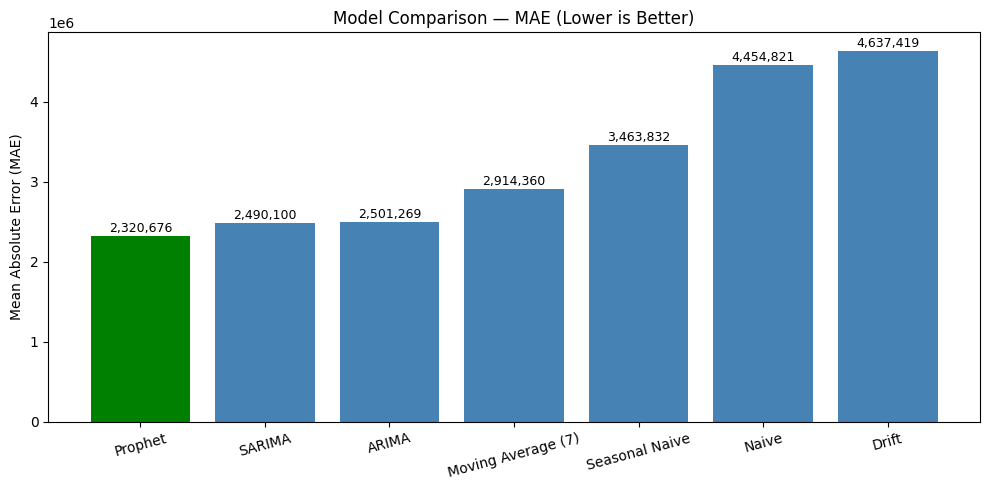

In [26]:
plt.figure(figsize=(10, 5))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(final_results))]
bars = plt.bar(final_results['Model'], final_results['MAE'], color=colors)

for bar, val in zip(bars, final_results['MAE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,f'{val:,.0f}', ha='center', fontsize=9)

plt.title('Model Comparison — MAE (Lower is Better)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

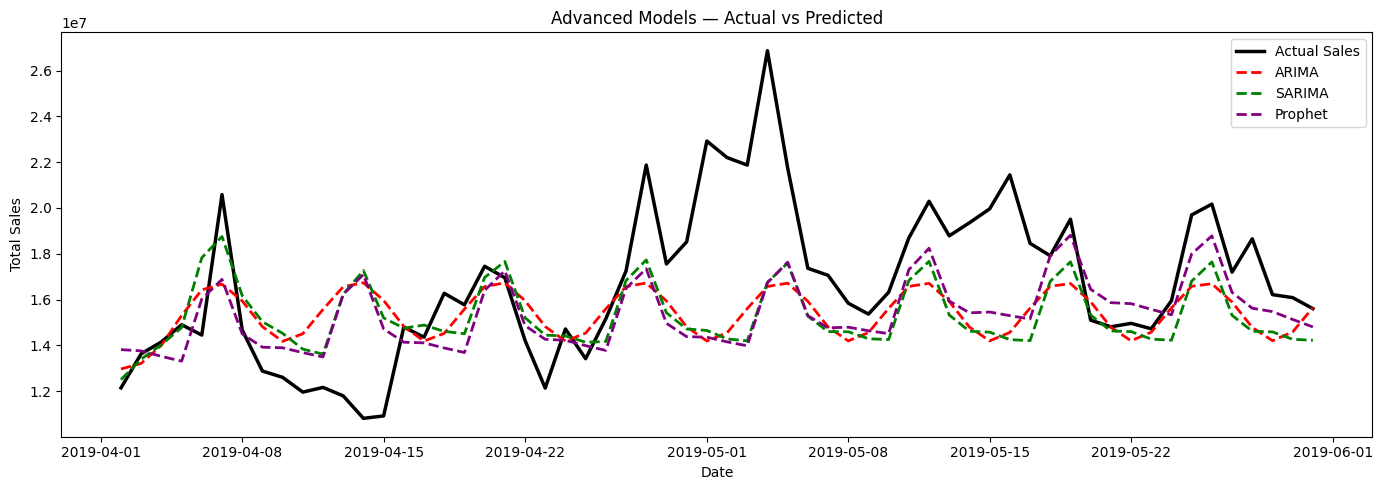

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(test['Date'].values, actual, color='black', linewidth=2.5, label='Actual Sales')
plt.plot(test['Date'].values, arima_pred, linewidth=2, linestyle='--', color='red', label='ARIMA')
plt.plot(test['Date'].values, sarima_pred, linewidth=2, linestyle='--', color='green', label='SARIMA')
plt.plot(test['Date'].values, prophet_pred, linewidth=2, linestyle='--', color='purple', label='Prophet')

plt.title('Advanced Models — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()